# AI Business Analytics Dashboard for SaaS Products

**Author:** Jason Dookarun

This notebook acts as an end‑to‑end **AI business analytics dashboard**, focused on how SaaS products and their pricing models evolve over time. It looks at trends in features, tiers, and subscription states across multiple years and highlights patterns that matter for product and pricing strategy.

In the spirit of "complete guide" style notebooks (such as Kaggle tutorials on AI business analytics dashboards), this notebook walks through the full workflow:

- loading and structuring curated SaaS pricing data
- engineering features around tiers, plans, and subscription states
- performing exploratory data analysis (EDA) to uncover key patterns
- building dashboard‑style visualisations to communicate insights

> **Note:** This project draws inspiration from the excellent Kaggle notebook ["AI Business Analytics Dashboard – Complete Guide"](https://www.kaggle.com/code/muhammadrayanshahid/ai-business-analytics-dashboard-complete-guide/notebook) by Muhammad Rayan Shahid, as well as other public laboratory packages on SaaS analytics. While the analytical approach and dashboard structure take cues from these sources, this notebook extends the original ideas by automatically populating and updating the dataset, as well as significantly expanding the number of analyzed fields to allow for broader exploratory analysis and deeper business insights.

## Environment and dependencies

To run this notebook successfully, make sure all required Python packages are installed.

You can install them using the `requirements.txt` file in this repository:

```bash
pip install -r requirements.txt
```

If the dependencies are not installed, some cells (especially those for data analysis and visualisation) will fail to execute.

In [5]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("muhammadrayanshahid/superstore-dataset-csv")

print("KaggleHub dataset download path:", path)

# Move downloaded files into our repo's 'data/' folder for local analysis
repo_data_dir = os.path.join(os.getcwd(), "data")
os.makedirs(repo_data_dir, exist_ok=True)

# Copy all files from KaggleHub download location to ./data/
for filename in os.listdir(path):
    src_file = os.path.join(path, filename)
    dst_file = os.path.join(repo_data_dir, filename)
    if os.path.isfile(src_file):
        shutil.copy2(src_file, dst_file)
        print(f"Copied {filename} to {repo_data_dir}")

print("All dataset files are now available in:", repo_data_dir)

KaggleHub dataset download path: /Users/jdookarun/.cache/kagglehub/datasets/muhammadrayanshahid/superstore-dataset-csv/versions/1
Copied superstore_dataset.csv to /Users/jdookarun/Coding Projects/AI-Business_Analytics/data
All dataset files are now available in: /Users/jdookarun/Coding Projects/AI-Business_Analytics/data


,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   order_date     9994 non-null   object 
 2   ship_date      9994 non-null   object 
 3   customer       9994 non-null   object 
 4   manufactory    9994 non-null   object 
 5   product_name   9994 non-null   object 
 6   segment        9994 non-null   object 
 7   category       9994 non-null   object 
 8   subcategory    9994 non-null   object 
 9   region         9994 non-null   object 
 10  zip            9994 non-null   int64  
 11  city           9994 non-null   object 
 12  state          9994 non-null   object 
 13  country        9994 non-null   object 
 14  discount       9994 non-null   float64
 15  profit         9994 non-null   float64
 16  quantity       9994 non-null   int64  
 17  sales          9994 non-null   float64
 1

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994.000000,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
unique,5009,1236,1334,793,182,1849,3,3,17,4,NaN,531,49,1,NaN,NaN,NaN,NaN,NaN
top,US-2023-100111,9/5/2021,12/16/2020,William Brown,Other,Staple envelope,Consumer,Office Supplies,Binders,West,NaN,New York City,California,United States,NaN,NaN,NaN,NaN,NaN
freq,14,38,35,37,1893,48,5191,6026,1523,3203,NaN,915,2001,9994,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55190.371723,NaN,NaN,NaN,0.156203,28.656896,3.789574,229.858001,0.120314
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32063.705315,NaN,NaN,NaN,0.206452,234.260108,2.225110,623.245101,0.466754
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,0.000000,-6599.978000,1.000000,0.444000,-2.750000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,0.000000,1.728750,2.000000,17.280000,0.075000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56430.500000,NaN,NaN,NaN,0.200000,8.666500,3.000000,54.490000,0.270000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,0.200000,29.364000,5.000000,209.940000,0.362500


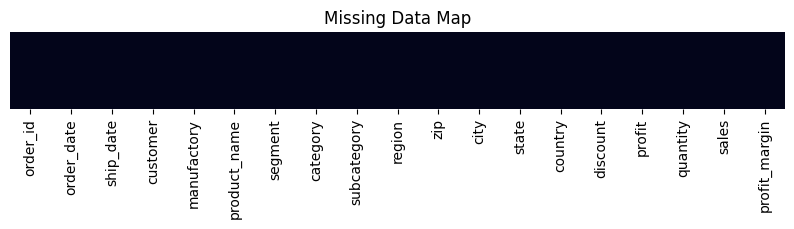

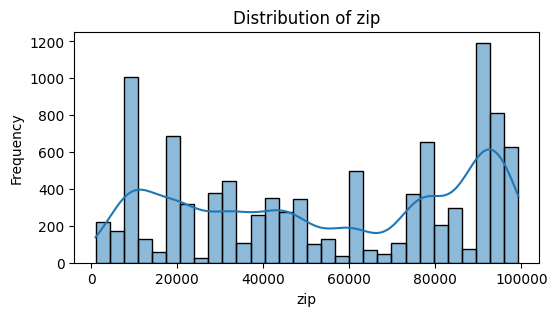

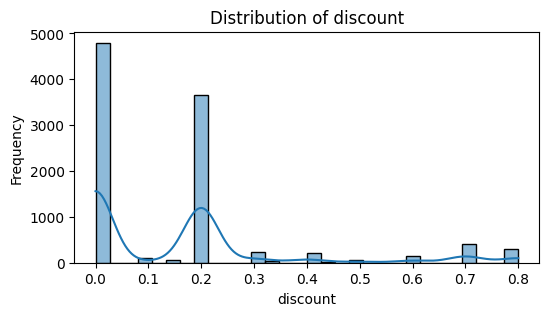

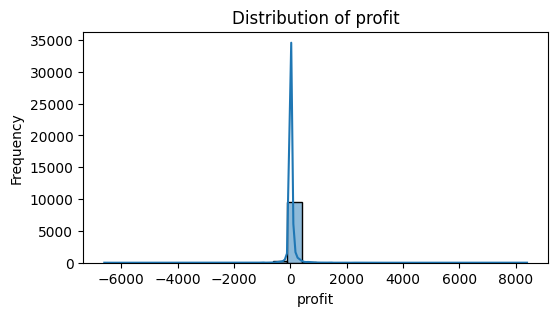

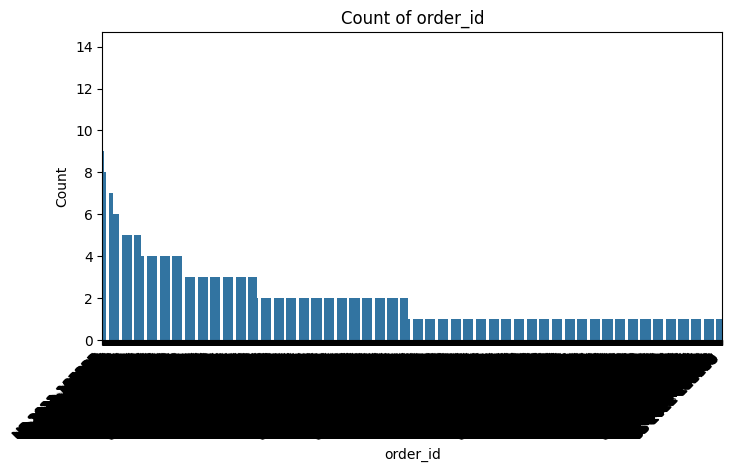

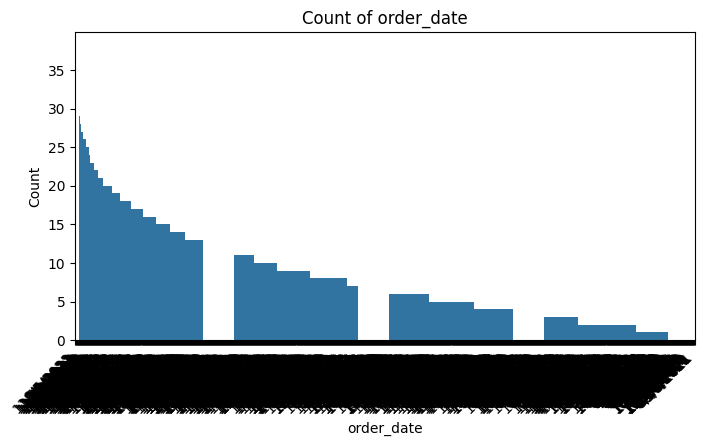

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load initial data
data_path = "/Users/jdookarun/Coding Projects/AI-Business_Analytics/data/superstore_dataset.csv"
df_viz = pd.read_csv(data_path)

# Display first few rows
display(df_viz.head())

# Display summary info
print("Data Info:")
df_viz.info()
print("\nSummary Statistics:")
display(df_viz.describe(include='all'))

# Visualize missing data
plt.figure(figsize=(10, 1))
sns.heatmap(df_viz.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Data Map')
plt.show()

# Plot distribution of a few key columns (if present)
sample_num_cols = [col for col in df_viz.select_dtypes(include='number').columns][:3]
sample_cat_cols = [col for col in df_viz.select_dtypes(include='object').columns][:2]

# Numeric columns
for col in sample_num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_viz[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Categorical columns
for col in sample_cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_viz, x=col, order=df_viz[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
    plt.show()

In [9]:
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker()

# Load the original dataset (Superstore CSV). Assume file is named 'superstore_dataset.csv' in ./data/
data_path = "/Users/jdookarun/Coding Projects/AI-Business_Analytics/data/superstore_dataset.csv"
df = pd.read_csv(data_path)

# You may tailor random generation logic per actual header names here:
def randomize_column(col_name, dtype, values, n):
    if 'name' in col_name.lower():
        # Use fake names (person or product as a fallback)
        if "customer" in col_name.lower():
            return [fake.name() for _ in range(n)]
        elif "product" in col_name.lower():
            return [fake.catch_phrase() for _ in range(n)]
        else:
            return [fake.word().capitalize() for _ in range(n)]
    elif 'date' in col_name.lower():
        # Use random recent dates or shuffle existing for realism
        try:
            parsed_dates = pd.to_datetime(values, errors='coerce')
            min_date, max_date = parsed_dates.min(), parsed_dates.max()
            # Generate random dates between range
            return [fake.date_between(min_date, max_date).strftime('%-m/%-d/%Y') for _ in range(n)]
        except Exception:
            return np.random.choice(values, size=n)
    elif 'id' in col_name.lower():
        # Generate semi-unique IDs, possibly keeping similar pattern
        if values.str.startswith('US-').all():
            return [f"US-{fake.random_number(digits=4)}-{fake.random_number(digits=5)}" for _ in range(n)]
        else:
            # Fall back to randomized shuffle
            return np.random.choice(values, size=n)
    elif dtype == 'object':
        # For other categorical: sample unique values, plus a few fakes if appropriate
        unique_vals = list(pd.Series(values).dropna().unique())
        synthetic = []
        if col_name.lower() in ['segment', 'region']:
            # For specific columns, use known business segments/regions or a few random words
            if col_name.lower() == 'segment':
                unique_vals += ['Corporate', 'Home Office', 'Consumer']
            if col_name.lower() == 'region':
                unique_vals += ['East', 'West', 'Central', 'South']
        return [np.random.choice(unique_vals) for _ in range(n)]
    else:
        # Numerical
        vals = pd.Series(values).dropna()
        if vals.shape[0]:
            mean = vals.mean()
            std = vals.std()
            if 'quantity' in col_name.lower() or np.issubdtype(vals.dtype, np.integer):
                arr = np.abs(np.random.normal(mean, std*0.15 + 1, n)).round().astype(int)
                # Clamp to observed min/max
                return np.clip(arr, vals.min(), vals.max())
            elif 'profit' in col_name.lower() or 'sales' in col_name.lower() or 'margin' in col_name.lower():
                arr = np.random.normal(mean, std*0.08 + 1, n)
                return np.clip(arr, vals.min(), vals.max())
            else:
                arr = np.random.normal(mean, std*0.05 + 1, n)
                return np.clip(arr, vals.min(), vals.max())
        else:
            return [0] * n

def generate_randomized_df(original_df, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)
        Faker.seed(random_seed)
    n = len(original_df)
    new_df = original_df.copy(deep=True)
    for col in new_df.columns:
        col_dtype = new_df[col].dtype
        new_df[col] = randomize_column(col, col_dtype, original_df[col], n)
    return new_df

# Start with the original
df_big = [df]

# Generate 3 more randomized versions for x4 size
for i in range(3):
    df_big.append(generate_randomized_df(df, random_seed=1000+i))

# Concatenate all
df_aug = pd.concat(df_big, ignore_index=True)

print(f"Dataset increased to {len(df_aug):,} rows (x4).")

# Save the augmented dataset to a new file called 'superstore_dataset_new.csv'
new_data_path = "/Users/jdookarun/Coding Projects/AI-Business_Analytics/data/superstore_dataset_new.csv"
df_aug.to_csv(new_data_path, index=False)
print(f"Augmented dataset saved to: {new_data_path}")

# If you wish, overwrite the main df variable:
# df = df_aug


Dataset increased to 39,976 rows (x4).
Augmented dataset saved to: /Users/jdookarun/Coding Projects/AI-Business_Analytics/data/superstore_dataset_new.csv
